In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

Hago todas las funciones para cargar imagenes

In [11]:
def cargar_imagen(path):
    
    imagen = cv2.imread(path, cv2.IMREAD_GRAYSCALE) #leo la imagen
    _, imagen_binaria = cv2.threshold(imagen, 128, 255, cv2.THRESH_BINARY) 
    # Convertir la imagen binaria a valores -1 y 1
    patron = (imagen_binaria / 255.0) * 2 - 1
    return patron.flatten(), imagen.shape

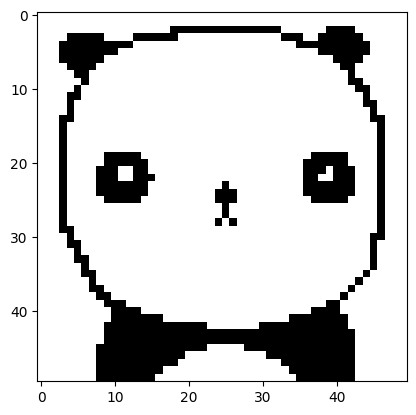

In [10]:
import cv2
import numpy as np

class RedHopfield:

    def __init__(self, num_neuronas):
        self.num_neuronas = num_neuronas
        self.pesos = np.zeros((num_neuronas, num_neuronas))



    def entrenar(self, patrones):
        """
        Entrenar la red con una lista de patrones.
        """
        for patron in patrones:
            patron = patron.reshape(-1, 1)  # Convertir a columna
            self.pesos += patron @ patron.T
        np.fill_diagonal(self.pesos, 0)  # Evitar auto-conexiones




def recuperar_imagen(red, patron_vector, shape_original):
    """
    Recuperar el patrón y devolverlo como imagen.
    """
    patron_recuperado = red.recuperar(patron_vector)
    return patron_recuperado.reshape(shape_original)

def mostrar_imagen(imagen, nombre_archivo='imagen_recuperada.bmp'):
    """
    Mostrar y guardar la imagen recuperada.
    """
    # Convertir valores de -1,1 a 0,255
    imagen_visualizar = (imagen + 1) * 127.5
    imagen_visualizar = imagen_visualizar.astype(np.uint8)
    cv2.imshow(nombre_archivo, imagen_visualizar)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    plt.imshow(imagen_visualizar, cmap='gray')

# Cargar la imagen y convertirla a vector
patron_vector, shape_original = cargar_imagen('panda.bmp')

# Inicializar y entrenar la red de Hopfield
red = RedHopfield(num_neuronas=len(patron_vector))
red.entrenar([patron_vector])

# Recuperar el patrón
imagen_recuperada = recuperar_imagen(red, patron_vector, shape_original)

# Mostrar la imagen recuperada
mostrar_imagen(imagen_recuperada)

In [ ]:
# Cargar la imagen y convertirla a vector
patron_vector, shape_original = cargar_imagen('panda.bmp')